In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [2]:
# Load dataset into python
df = pd.read_csv("house_prices_practice.csv.csv")

In [3]:
# View first rows of dataset
print(df.head())

   Id  OverallQual  GrLivArea  GarageCars  TotalBsmtSF  YearBuilt  FullBath  \
0   1            7       1560           0         1658       1969         2   
1   2            4       2827           2         1319       2012         3   
2   3            8       3920           0          841       2010         1   
3   4            5       3044           0         1058       1998         0   
4   5            7        801           1         2428       2020         0   

   BedroomAbvGr  LotArea  SalePrice  
0             1     8059     177106  
1             4    13530     301044  
2             4     9010     360609  
3             4    13207     240556  
4             1     9117     193656  


In [4]:
# Dataset information:;- check datatypes and null values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            300 non-null    int64
 1   OverallQual   300 non-null    int64
 2   GrLivArea     300 non-null    int64
 3   GarageCars    300 non-null    int64
 4   TotalBsmtSF   300 non-null    int64
 5   YearBuilt     300 non-null    int64
 6   FullBath      300 non-null    int64
 7   BedroomAbvGr  300 non-null    int64
 8   LotArea       300 non-null    int64
 9   SalePrice     300 non-null    int64
dtypes: int64(10)
memory usage: 23.6 KB
None


In [5]:
# check rows and columns count
print(df.shape)

(300, 10)


In [24]:
print(df.columns)

num_cols = df.select_dtypes(include=["int64", "float64"]).columns
print("Numeric columns: ")
print(num_cols)
cat_cols = df.select_dtypes(include=["object"]).columns
print("Categorie columns: ")
print(cat_cols)

binary_cols = [col for col in cat_cols if df[col].nunique() == 2]
multi_cols = [col for col in cat_cols if df[col].nunique() > 2]
print("Binary:", binary_cols)
print("Multi-category:", multi_cols)

Index(['Id', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
       'YearBuilt', 'FullBath', 'BedroomAbvGr', 'LotArea', 'SalePrice'],
      dtype='object')
Numeric columns: 
Index(['Id', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
       'YearBuilt', 'FullBath', 'BedroomAbvGr', 'LotArea', 'SalePrice'],
      dtype='object')
Categorie columns: 
Index([], dtype='object')
Binary: []
Multi-category: []


In [7]:
# Find missing values
print(df.isnull().sum())

Id              0
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64


In [8]:
# view statistical summary
print(df.describe())

               Id  OverallQual    GrLivArea  GarageCars  TotalBsmtSF  \
count  300.000000   300.000000   300.000000  300.000000   300.000000   
mean   150.500000     5.326667  2307.386667    1.330000  1468.796667   
std     86.746758     2.873001  1042.561303    1.109898   672.333705   
min      1.000000     1.000000   504.000000    0.000000   303.000000   
25%     75.750000     3.000000  1392.250000    0.000000   903.000000   
50%    150.500000     5.000000  2265.500000    1.000000  1502.000000   
75%    225.250000     8.000000  3306.500000    2.000000  2129.500000   
max    300.000000    10.000000  3998.000000    3.000000  2492.000000   

         YearBuilt    FullBath  BedroomAbvGr       LotArea      SalePrice  
count   300.000000  300.000000    300.000000    300.000000     300.000000  
mean   1986.163333    1.523333      2.926667   8969.453333  252262.903333  
std      21.377089    1.131543      1.456604   3753.531132   74998.055214  
min    1950.000000    0.000000      1.000000   

In [9]:
# Features:- Separate input and output data
x = df[[
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "YearBuilt",
    "FullBath",
    "BedroomAbvGr",
    "LotArea"
]]

# Target
y = df["SalePrice"]

In [10]:
# split dataset:- Split data into training and testing 
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
# Create model:- Create linear regression model
model=LinearRegression()

In [12]:
# Train model:-Train the model using training data
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
# predict:-predict output values
predict=model.predict(x_test)

In [14]:
# check errors
# MAE:-Calculate average prediction error
mae=mean_absolute_error(y_test,predict)
print(mae)

10431.655979707542


In [15]:
# MSE:- Calculate squared prediction error
mse=mean_squared_error(y_test,predict)
print(mse) 

156386511.41905734


In [16]:
# Compare outputs:- Compare actual and predicted values
comparison=pd.DataFrame({
    "Actual":y_test,
    "Predicted":predict
})
print(comparison)

     Actual      Predicted
203  224163  239161.363189
266  203881  190489.667985
152  380236  398000.957463
9    211664  223169.467552
233  122139  135188.395708
226  180067  180259.039807
196  275810  283708.271011
109  209025  204535.265477
5    213952  205837.941731
175  154885  171505.331960
237  395010  389527.701784
57   253397  274163.797399
218  115204  116220.902124
45   189831  171343.531633
182  300918  293879.431887
221  314526  314821.031567
289  135263  154945.462755
211  135385  146162.968604
148  222449  221221.028134
165  250335  255128.948650
78   221041  235772.515720
113  175831  167430.542668
249  206832  208978.167075
250  296330  289813.475790
104  319876  313188.748976
42   385176  382651.913132
281  225589  206610.720434
295  250604  260775.037167
157  289461  285214.273370
238  424406  443345.986717
17   397482  402224.276978
164  290763  292287.651573
33   137842  122222.085736
24   204186  211039.072251
215  294974  291045.644458
119  212206  226581.772854
7

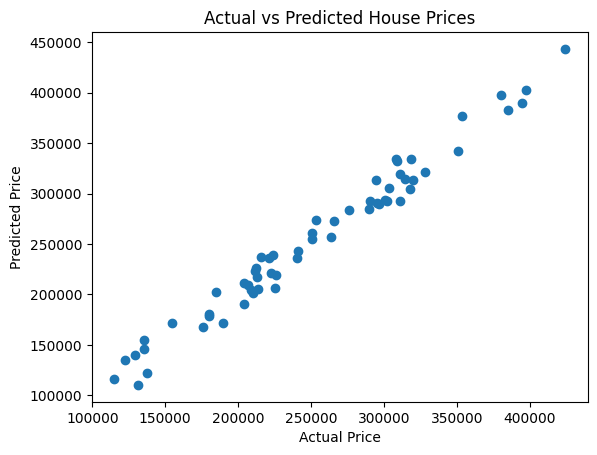

In [17]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predict)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

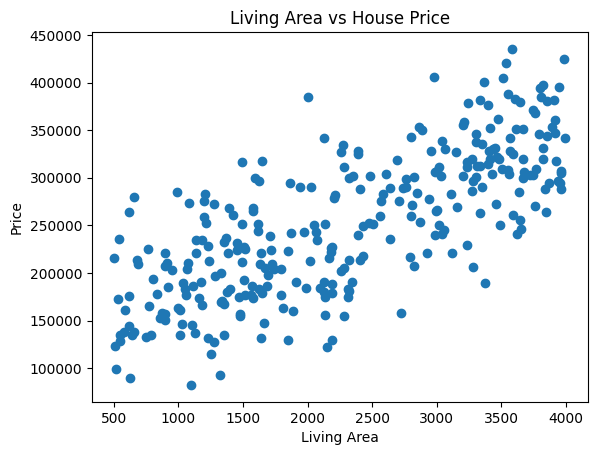

In [18]:
plt.scatter(df["GrLivArea"], df["SalePrice"])
plt.xlabel("Living Area")
plt.ylabel("Price")
plt.title("Living Area vs House Price")
plt.show()

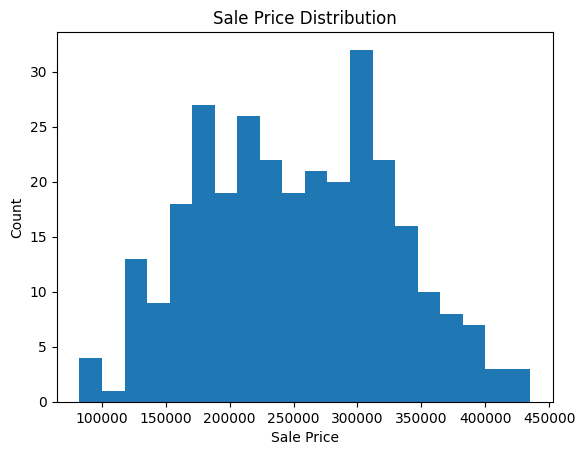

In [19]:
plt.hist(df["SalePrice"], bins=20)

plt.title("Sale Price Distribution")
plt.xlabel("Sale Price")
plt.ylabel("Count")

plt.show()

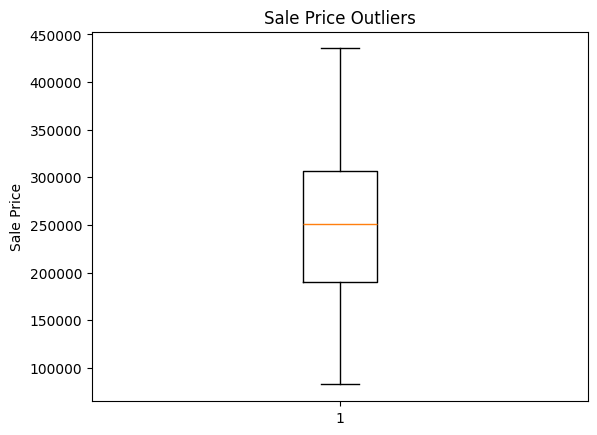

In [20]:
plt.boxplot(df["SalePrice"])

plt.title("Sale Price Outliers")
plt.ylabel("Sale Price")

plt.show()

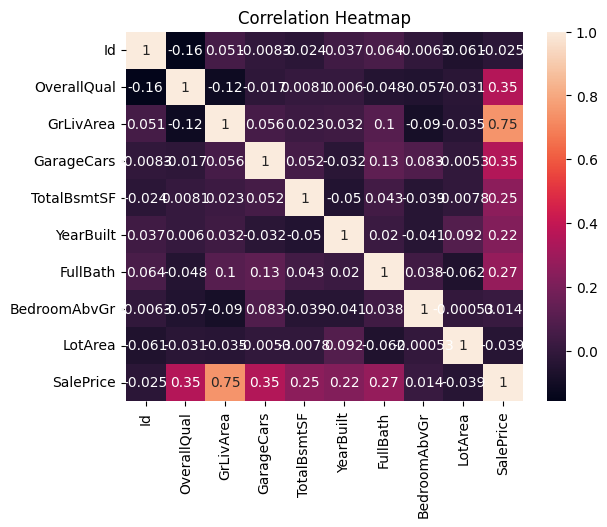

In [21]:
import seaborn as sns

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()